In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import ta
import pandas_ta as pta

# Load data
AMZN_path = "C:/Users/yhsol/Downloads/AMZN_alpha_1min_2024-05_to_2025-05 (1).csv"
df = pd.read_csv(AMZN_path)

df['timestamp'] = pd.to_datetime(df['Timestamp'])
df.sort_values('timestamp', inplace=True)
df.set_index('timestamp', inplace=True)
df.drop(columns=['Timestamp'], inplace=True, errors='ignore')
df = df.between_time('09:30', '16:00')

# PSAR
df['PSAR'] = ta.trend.PSARIndicator(df['High'], df['Low'], df['Close'], step=0.02, max_step=0.2).psar()

# STD (Standard Deviation)
std_length = 20
df['STD'] = df['Close'].rolling(window=std_length).std()

# RCI
def rci(series, period=14):
    result = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        price = series[i - period + 1:i + 1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff ** 2)) / (period * (period ** 2 - 1))) * 100
        result[i] = rci_value
    return result

df['RCI_14'] = rci(df['Close'], period=14)

# Ichimoku
ichi = ta.trend.IchimokuIndicator(df['High'], df['Low'], window1=9, window2=26, window3=52, visual=False)
df['Tenkan_Sen'] = ichi.ichimoku_conversion_line()
df['Kijun_Sen'] = ichi.ichimoku_base_line()
df['Senkou_Span_A'] = ichi.ichimoku_a()
df['Senkou_Span_B'] = ichi.ichimoku_b()
df['Chikou_Span'] = df['Close'].shift(26)

# AO (Awesome Oscillator)
median_price = (df['High'] + df['Low']) / 2
df['AO'] = median_price.rolling(window=5).mean() - median_price.rolling(window=34).mean()

# CMF (Chaikin Money Flow)
def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

df['CMF'] = chaikin_money_flow(df, window=20)

# ADX
adx = ta.trend.ADXIndicator(df['High'], df['Low'], df['Close'], window=14)
df['ADX'] = adx.adx()

# Envelope Upper
sma_length = 20
df['SMA'] = df['Close'].rolling(window=sma_length).mean()
df['Upper_Envelope'] = df['SMA'] * (1 + 0.02)

# Williams %R
df['WilliamsR'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'], lbp=14, fillna=True)

# Stochastic Oscillator %K
df['Stoch_K'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'], window=14, smooth_window=3, fillna=True)

# Drop missing
df.dropna(inplace=True)

# Target (Direction)
noise_thresh = 0.0001
df['Return'] = df['Close'].pct_change().shift(-1)
df['Direction'] = np.where(df['Return'] > noise_thresh, 1,
                    np.where(df['Return'] < -noise_thresh, 0, np.nan))
df.dropna(subset=['Direction'], inplace=True)
df['Direction'] = df['Direction'].astype(int)

# Features for model
feature_cols = [
    'STD', 'RCI_14',
    'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span',
    'AO', 'CMF', 'ADX', 'Upper_Envelope',
    'WilliamsR', 'Stoch_K', 'PSAR'
]
X = df[feature_cols]
y = df['Direction']

# Train-test split
split_index = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
returns_test = df['Return'].iloc[split_index:]

# XGBoost + Random Search
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    booster='gbtree',
    tree_method='exact',
    predictor='cpu_predictor',
    use_label_encoder=False,
    random_state=42
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=4,
    error_score='raise'
)

search.fit(X_train, y_train)

# Evaluation
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best Parameters: {search.best_params_}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:38:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}

Accuracy: 0.5022

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.32      0.39     12366
           1       0.50      0.68      0.58     12453

    accuracy                           0.50     24819
   macro avg       0.50      0.50      0.48     24819
weighted avg       0.50      0.50      0.48     24819

Confusion Matrix:
 [[3942 8424]
 [3931 8522]]


In [12]:
import numpy as np

# Predict probabilities and labels
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

# Assign predictions
df_test = df.iloc[split_index:].copy()
df_test['Predicted'] = y_pred

# Filter trades (model predicted 1)
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
num_trades = len(trade_return)

# Trading fee
fee_per_trade = 0.0001
trade_return_with_fee = trade_return - fee_per_trade

# Add trading date
df_test['trading_Date'] = df_test.index.date

# Group returns per day
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
daily_return = trade_date.groupby('trading_Date')['Return'].sum()  # without fee

# Count trades per day
daily_trades_count = df_test[df_test['Predicted'] == 1].groupby('trading_Date').size()

# Daily return with fee
daily_return_with_fee = daily_return - (daily_trades_count * fee_per_trade)

# Metrics
average_daily_return = daily_return.mean()
average_daily_return_with_fee = daily_return_with_fee.mean()
total_trade_return = trade_return_with_fee.sum() * 100
average_trade_return = trade_return_with_fee.mean()
cumulative_return = (np.prod(1 + trade_return_with_fee) - 1) * 100

# Output
print(f"\n🔍 Trade Evaluation Metrics (with $4/1000 trade fee):")
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.2f}%")
print(f"Average Daily Return (no fee): {average_daily_return:.4f}")
print(f"Average Daily Return (with fee): {average_daily_return_with_fee:.4f}")
print(f"Number of Trades: {num_trades}")
print(f"Average Return per Trade (with fee): {average_trade_return:.4f}")



🔍 Trade Evaluation Metrics (with $4/1000 trade fee):
Cumulative Return: -32.94%
Total Sum of Return: -38.27%
Average Daily Return (no fee): 0.0166
Average Daily Return (with fee): -0.0052
Number of Trades: 15979
Average Return per Trade (with fee): -0.0000


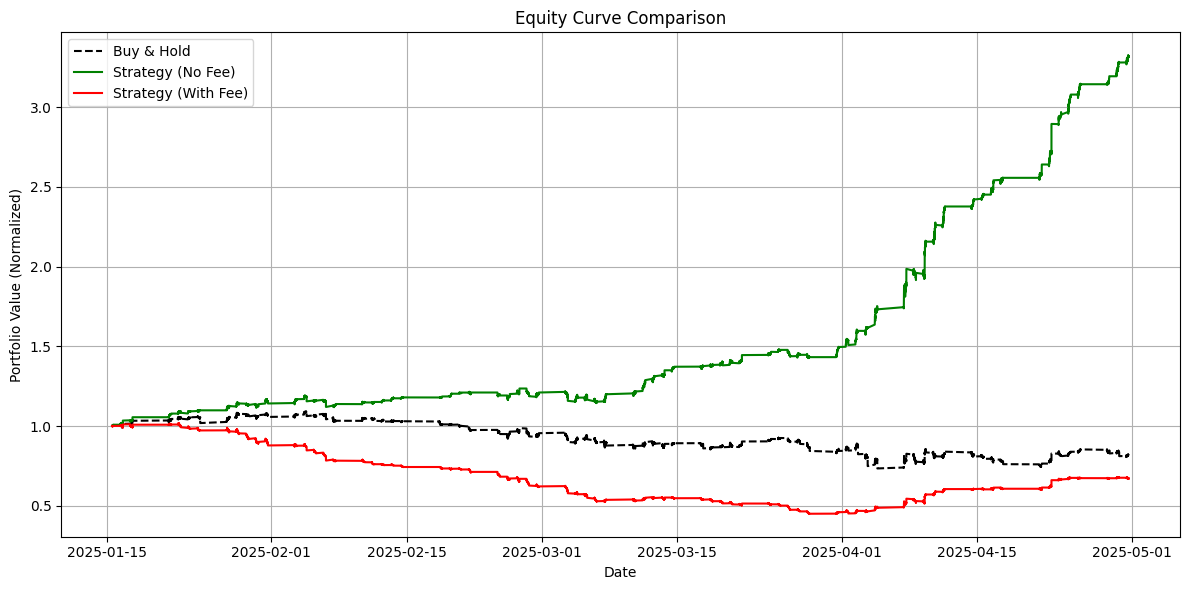

In [13]:
import matplotlib.pyplot as plt


buy_hold_return = df_test['Return'].cumsum()  
buy_hold_equity = (1 + df_test['Return']).cumprod()  

trade_equity_no_fee = (1 + trade_return).cumprod()
trade_equity_with_fee = (1 + trade_return_with_fee).cumprod()

equity_curve_no_fee = pd.Series(index=df_test.index, dtype=float)
equity_curve_with_fee = pd.Series(index=df_test.index, dtype=float)

equity_curve_no_fee.loc[df_test['Predicted'] == 1] = trade_equity_no_fee.values
equity_curve_with_fee.loc[df_test['Predicted'] == 1] = trade_equity_with_fee.values

equity_curve_no_fee.ffill(inplace=True)
equity_curve_with_fee.ffill(inplace=True)


equity_curve_no_fee.fillna(1, inplace=True)
equity_curve_with_fee.fillna(1, inplace=True)


plt.figure(figsize=(12, 6))
plt.plot(df_test.index, buy_hold_equity, label='Buy & Hold', color='black', linestyle='--')
plt.plot(df_test.index, equity_curve_no_fee, label='Strategy (No Fee)', color='green')
plt.plot(df_test.index, equity_curve_with_fee, label='Strategy (With Fee)', color='red')
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import ta
import pandas_ta as pta

# Load and resample to 2-minute intervals
AMZN_path = "C:/Users/yhsol/Downloads/AMZN_alpha_1min_2024-05_to_2025-05 (1).csv"
df = pd.read_csv(AMZN_path)

df['timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('timestamp', inplace=True)
df = df.between_time('09:30', '16:00')
df = df.resample('2T').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

# PSAR
df['PSAR'] = ta.trend.PSARIndicator(df['High'], df['Low'], df['Close'], step=0.02, max_step=0.2).psar()

# MACD
macd = ta.trend.MACD(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

# Bollinger Bands MAVG (Middle Band)
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_MAVG'] = bb.bollinger_mavg()

# SMA
df['SMA'] = df['Close'].rolling(window=20).mean()

# RCI
def rci(series, period=14):
    result = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        price = series[i - period + 1:i + 1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff ** 2)) / (period * (period ** 2 - 1))) * 100
        result[i] = rci_value
    return result

df['RCI_14'] = rci(df['Close'], period=14)

# MA Envelope (Upper and Lower)
df['MA'] = df['Close'].rolling(window=20).mean()
df['Envelope_Upper'] = df['MA'] * (1 + 0.02)
df['Envelope_Lower'] = df['MA'] * (1 - 0.02)

# IBS (Internal Bar Strength)
df['IBS'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

# AO (Awesome Oscillator)
median_price = (df['High'] + df['Low']) / 2
df['AO'] = median_price.rolling(window=5).mean() - median_price.rolling(window=34).mean()

# CMO (Chande Momentum Oscillator)
df['CMO'] = pta.cmo(df['Close'], length=14)

# ROC (Rate of Change)
df['ROC'] = ta.momentum.ROCIndicator(df['Close'], window=12).roc()

# Drop missing values
df.dropna(inplace=True)

# Create direction target
noise_thresh = 0.0001
df['Return'] = df['Close'].pct_change().shift(-1)
df['Direction'] = np.where(df['Return'] > noise_thresh, 1,
                    np.where(df['Return'] < -noise_thresh, 0, np.nan))
df.dropna(subset=['Direction'], inplace=True)
df['Direction'] = df['Direction'].astype(int)

# Feature columns
feature_cols = [
    'PSAR', 'MACD', 'MACD_Signal', 'BB_MAVG',
    'SMA', 'RCI_14', 'Envelope_Upper', 'Envelope_Lower',
    'IBS', 'AO', 'CMO', 'ROC'
]
X = df[feature_cols]
y = df['Direction']

# Train-test split
split_index = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# XGBoost tuning
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=4,
    error_score='raise'
)

search.fit(X_train, y_train)

# Evaluation
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best Parameters: {search.best_params_}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:57:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 1.0}

Accuracy: 0.5015

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.45      0.47      6546
           1       0.50      0.55      0.53      6541

    accuracy                           0.50     13087
   macro avg       0.50      0.50      0.50     13087
weighted avg       0.50      0.50      0.50     13087

Confusion Matrix:
 [[2951 3595]
 [2929 3612]]


In [15]:
import numpy as np

# Predict probabilities and labels
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

# Assign predictions
df_test = df.iloc[split_index:].copy()
df_test['Predicted'] = y_pred

# Filter trades (model predicted 1)
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
num_trades = len(trade_return)

# Trading fee
fee_per_trade = 0.0001
trade_return_with_fee = trade_return - fee_per_trade

# Add trading date
df_test['trading_Date'] = df_test.index.date

# Group returns per day
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
daily_return = trade_date.groupby('trading_Date')['Return'].sum()  # without fee

# Count trades per day
daily_trades_count = df_test[df_test['Predicted'] == 1].groupby('trading_Date').size()

# Daily return with fee
daily_return_with_fee = daily_return - (daily_trades_count * fee_per_trade)

# Metrics
average_daily_return = daily_return.mean()
average_daily_return_with_fee = daily_return_with_fee.mean()
total_trade_return = trade_return_with_fee.sum() * 100
average_trade_return = trade_return_with_fee.mean()
cumulative_return = (np.prod(1 + trade_return_with_fee) - 1) * 100

# Output
print(f"\n🔍 Trade Evaluation Metrics (with $4/1000 trade fee):")
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.2f}%")
print(f"Average Daily Return (no fee): {average_daily_return:.4f}")
print(f"Average Daily Return (with fee): {average_daily_return_with_fee:.4f}")
print(f"Number of Trades: {num_trades}")
print(f"Average Return per Trade (with fee): {average_trade_return:.4f}")



🔍 Trade Evaluation Metrics (with $4/1000 trade fee):
Cumulative Return: -57.28%
Total Sum of Return: -83.28%
Average Daily Return (no fee): -0.0015
Average Daily Return (with fee): -0.0114
Number of Trades: 7207
Average Return per Trade (with fee): -0.0001


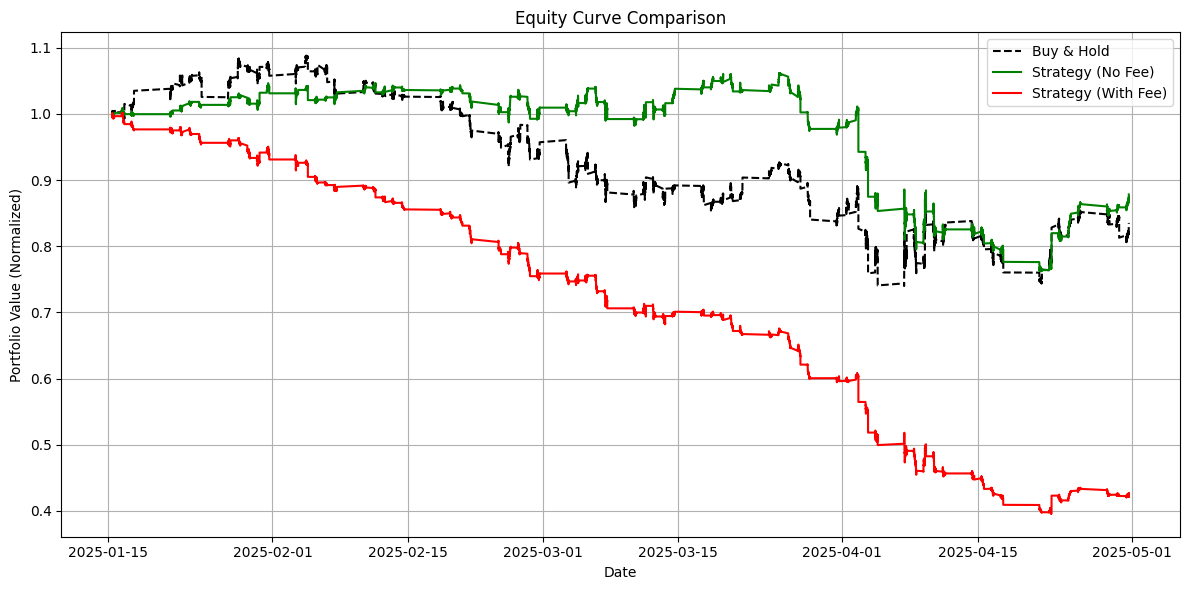

In [16]:
import matplotlib.pyplot as plt


buy_hold_return = df_test['Return'].cumsum()  
buy_hold_equity = (1 + df_test['Return']).cumprod()  

trade_equity_no_fee = (1 + trade_return).cumprod()
trade_equity_with_fee = (1 + trade_return_with_fee).cumprod()

equity_curve_no_fee = pd.Series(index=df_test.index, dtype=float)
equity_curve_with_fee = pd.Series(index=df_test.index, dtype=float)

equity_curve_no_fee.loc[df_test['Predicted'] == 1] = trade_equity_no_fee.values
equity_curve_with_fee.loc[df_test['Predicted'] == 1] = trade_equity_with_fee.values

equity_curve_no_fee.ffill(inplace=True)
equity_curve_with_fee.ffill(inplace=True)


equity_curve_no_fee.fillna(1, inplace=True)
equity_curve_with_fee.fillna(1, inplace=True)


plt.figure(figsize=(12, 6))
plt.plot(df_test.index, buy_hold_equity, label='Buy & Hold', color='black', linestyle='--')
plt.plot(df_test.index, equity_curve_no_fee, label='Strategy (No Fee)', color='green')
plt.plot(df_test.index, equity_curve_with_fee, label='Strategy (With Fee)', color='red')
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np
import pandas_ta as ta


df = pd.read_csv("C:/Users/yhsol/Downloads/AMZN_alpha_1min_2024-05_to_2025-05 (1).csv")
df['timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('timestamp', inplace=True)
df = df.between_time("09:30", "16:00").sort_index()
df.drop(columns=['Timestamp'], inplace=True, errors='ignore')

# --- PSAR ---
df['PSAR'] = ta.psar(df['High'], df['Low'], df['Close'], step=0.02, max_step=0.2)['PSARl_0.02_0.2']

# --- Bollinger Bands (BB upper band as 'BB') ---
bb = ta.bbands(df['Close'], length=20)
df['BB'] = bb['BBU_20_2.0']

# --- Envelope ---
env_length = 20
env_dev = 0.02
df['Envelope_SMA'] = df['Close'].rolling(env_length).mean()
df['Upper_Envelope'] = df['Envelope_SMA'] * (1 + env_dev)
df['Lower_Envelope'] = df['Envelope_SMA'] * (1 - env_dev)

# --- Awesome Oscillator (AO) ---
df['AO'] = ta.ao(df['High'], df['Low'])

# --- CMO (custom) ---
def cmo(series, period=14):
    delta = series.diff()
    up = delta.where(delta > 0, 0).rolling(period).sum()
    down = (-delta.where(delta < 0, 0)).rolling(period).sum()
    cmo = 100 * (up - down) / (up + down)
    return cmo
df['CMO'] = cmo(df['Close'], period=14)

# --- Standard Deviation (20-period) ---
df['STD'] = df['Close'].rolling(20).std()

# --- Ichimoku Conversion Line (Tenkan-sen) ---
ichi = ta.ichimoku(df['High'], df['Low'], df['Close'])
df['Ichimoku'] = ichi[0].iloc[:, 0]  # Conversion line

# --- RCI (9 periods, custom) ---
def rci(series, period=9):
    result = np.full(len(series), np.nan)
    for i in range(period-1, len(series)):
        price = series.iloc[i-period+1:i+1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff**2)) / (period * (period**2 - 1))) * 100
        result[i] = rci_value
    return result
df['RCI'] = rci(df['Close'], period=9)

# --- MACD (macd line) ---
df['MACD'] = ta.macd(df['Close'])['MACD_12_26_9']

# --- RSI (14 periods) ---
df['RSI'] = ta.rsi(df['Close'], length=14)

# --- Williams %R ---
df['WilliamsR'] = ta.willr(df['High'], df['Low'], df['Close'], length=14)

# --- PPO ---
ppo_df = ta.ppo(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['PPO'] = ppo_df.iloc[:, 0]  # Or use ppo_df['PPO_12_26_9'] if you know the column name


# --- Stochastic Oscillator (K line) ---
df['Stoch'] = ta.stoch(df['High'], df['Low'], df['Close'])['STOCHk_14_3_3']

# --- Chaikin Money Flow (CMF) ---
df['CMF'] = ta.cmf(df['High'], df['Low'], df['Close'], df['Volume'], length=20)

# --- ROC ---
df['ROC'] = ta.roc(df['Close'], length=12)

# --- IBS (Internal Bar Strength) ---
df['IBS'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

# --- ADX ---
df['ADX'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']


df.dropna(inplace=True)

features = ['PSAR', 'BB', 'Envelope_SMA', 'Upper_Envelope', 'Lower_Envelope', 'AO', 'CMO', 'STD',
            'Ichimoku', 'RCI', 'MACD', 'RSI', 'WilliamsR', 'PPO', 'Stoch', 'CMF', 'ROC',
            'IBS', 'ADX']


data = []
for i in range(len(df) - 1):
    row = {}
    for f in features:
        row[f"{f}_T0"] = df.iloc[i][f]
        row[f"{f}_T1"] = df.iloc[i + 1][f]
    row['Close'] = df.iloc[i + 1]['Close']
    row['timestamp'] = df.index[i + 1]
    data.append(row)


df_pairs = pd.DataFrame(data)

df_2min = df_pairs.iloc[::2].reset_index(drop=True)


print("✅ df_2min shape:", df_2min.shape)
print(df_2min.head())



✅ df_2min shape: (24907, 40)
      PSAR_T0     PSAR_T1       BB_T0       BB_T1  Envelope_SMA_T0  \
0  179.233349  179.310681  181.045257  180.891240       179.964625   
1  179.381827  179.447280  180.764126  180.691701       179.877630   
2  179.507498  179.562898  180.661675  180.596990       179.835880   
3  179.580000  179.580000  180.491170  180.369799       179.782880   
4  179.642830  179.699377  180.381692  180.410920       179.751510   

   Envelope_SMA_T1  Upper_Envelope_T0  Upper_Envelope_T1  Lower_Envelope_T0  \
0       179.918130         183.563918         183.516493         176.365333   
1       179.851630         183.475183         183.448663         176.280077   
2       179.808380         183.432598         183.404548         176.239162   
3       179.746510         183.378538         183.341440         176.187222   
4       179.787505         183.346540         183.383255         176.156480   

   Lower_Envelope_T1  ...    CMF_T0    CMF_T1    ROC_T0    ROC_T1    IBS_T0

In [18]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


df_2min['Next_Close'] = df_2min['Close'].shift(-1)
df_2min['Return'] = (df_2min['Next_Close'] - df_2min['Close']) / df_2min['Close']
noise_thresh = 0.0001
df_2min['Direction'] = np.where(df_2min['Return'] > noise_thresh, 1,
                        np.where(df_2min['Return'] < -noise_thresh, 0, np.nan))
df_2min.dropna(subset=['Direction'], inplace=True)
df_2min['Direction'] = df_2min['Direction'].astype(int)

feature_cols = [col for col in df_2min.columns if col.endswith('_T0') or col.endswith('_T1')]
X = df_2min[feature_cols]
y = df_2min['Direction']

split_index = int(len(df_2min) * 0.7)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
returns_test = df_2min['Return'].iloc[split_index:]


param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    booster='gbtree',
    tree_method='exact',
    predictor='cpu_predictor',
    use_label_encoder=False,
    random_state=42
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=1,
    error_score='raise'
)

search.fit(X_train, y_train)


best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best Parameters: {search.best_params_}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:59:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:59:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:59:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\yhsol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: Us

Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}

Accuracy: 0.5498

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.20      0.28      2935
           1       0.57      0.83      0.67      3713

    accuracy                           0.55      6648
   macro avg       0.52      0.51      0.48      6648
weighted avg       0.53      0.55      0.50      6648

Confusion Matrix:
 [[ 579 2356]
 [ 637 3076]]


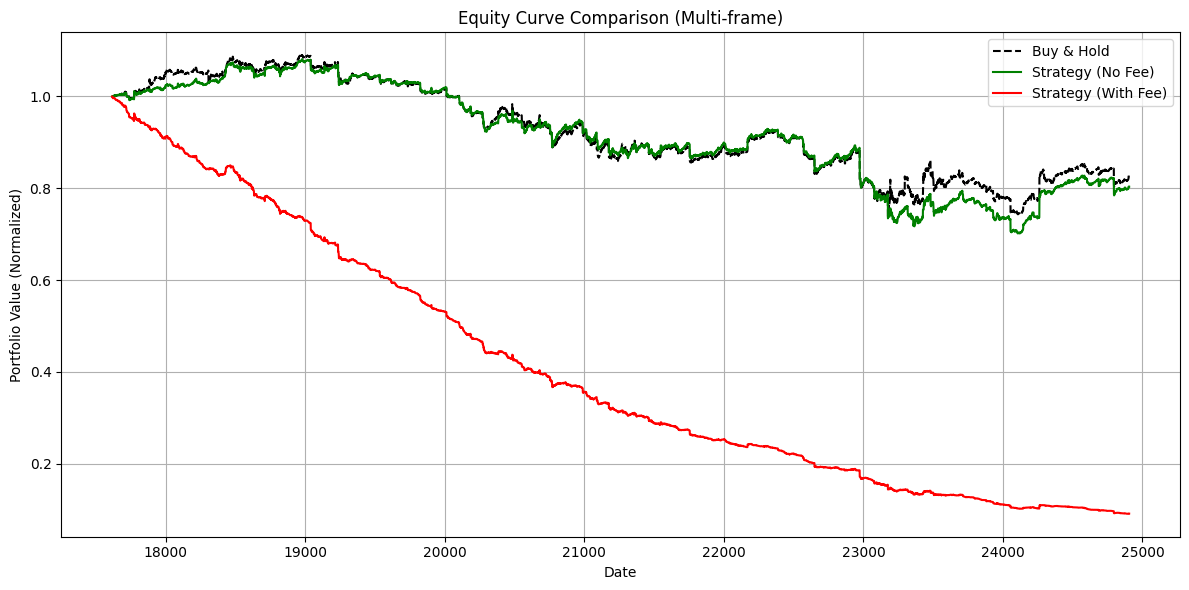

Number of Trades: 5432
returns wihout fee: -19.339336543113355


In [19]:
import matplotlib.pyplot as plt


df_test = df_2min.iloc[split_index:].copy()

y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)


df_test['Predicted'] = y_pred

fee_per_trade = 0.0004  # e.g. $4 per $10k trade


trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
trade_return_with_fee = trade_return - fee_per_trade

buy_hold_equity = (1 + df_test['Return']).cumprod()
strategy_equity_no_fee = (1 + trade_return).cumprod()
strategy_equity_with_fee = (1 + trade_return_with_fee).cumprod()

equity_curve_no_fee = pd.Series(index=df_test.index, dtype=float)
equity_curve_with_fee = pd.Series(index=df_test.index, dtype=float)

equity_curve_no_fee.loc[df_test['Predicted'] == 1] = strategy_equity_no_fee.values
equity_curve_with_fee.loc[df_test['Predicted'] == 1] = strategy_equity_with_fee.values

equity_curve_no_fee.ffill(inplace=True)
equity_curve_with_fee.ffill(inplace=True)
equity_curve_no_fee.fillna(1, inplace=True)
equity_curve_with_fee.fillna(1, inplace=True)


plt.figure(figsize=(12, 6))
plt.plot(df_test.index, buy_hold_equity, label='Buy & Hold', linestyle='--', color='black')
plt.plot(df_test.index, equity_curve_no_fee, label='Strategy (No Fee)', color='green')
plt.plot(df_test.index, equity_curve_with_fee, label='Strategy (With Fee)', color='red')
plt.title('Equity Curve Comparison (Multi-frame)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Number of Trades: {len(trade_return)}")
print("returns wihout fee:", trade_return.sum() * 100)

In [25]:
# Use the same data source as X_test
df_test = df_2min.iloc[split_index:].copy()

# Convert index to datetime
df_test.index = pd.to_datetime(df_test.index)

# Predict probabilities and labels
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

# Assign predictions
df_test['Predicted'] = y_pred

# Filter trades (where model predicted 1)
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
num_trades = len(trade_return)

# Trading fee
fee_per_trade = 0.0001
trade_return_with_fee = trade_return - fee_per_trade

# Add trading date
df_test['trading_Date'] = df_test.index.date

# Group returns per day
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
daily_return = trade_date.groupby('trading_Date')['Return'].sum()  # without fee

# Count trades per day
daily_trades_count = df_test[df_test['Predicted'] == 1].groupby('trading_Date').size()

# Daily return with fee
daily_return_with_fee = daily_return - (daily_trades_count * fee_per_trade)

# Metrics
average_daily_return = daily_return.mean()
average_daily_return_with_fee = daily_return_with_fee.mean()
total_trade_return = trade_return_with_fee.sum() * 100
average_trade_return = trade_return_with_fee.mean()
cumulative_return = (np.prod(1 + trade_return_with_fee) - 1) * 100

# Output
print(f"\n🔍 Trade Evaluation Metrics (with $4/1000 trade fee):")
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.2f}%")
print(f"Average Daily Return (no fee): {average_daily_return:.4f}")
print(f"Average Daily Return (with fee): {average_daily_return_with_fee:.4f}")
print(f"Number of Trades: {num_trades}")
print(f"Average Return per Trade (with fee): {average_trade_return:.4f}")



🔍 Trade Evaluation Metrics (with $4/1000 trade fee):
Cumulative Return: -53.35%
Total Sum of Return: -73.66%
Average Daily Return (no fee): -0.1934
Average Daily Return (with fee): -0.7366
Number of Trades: 5432
Average Return per Trade (with fee): -0.0001
